In [48]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [49]:
RAW_PATH = "../data/raw/DataCoSupplyChainDataset.csv"
PROCESSED_DIR = "../data/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)

In [50]:
df = pd.read_csv(RAW_PATH, encoding="latin1")

print("Shape:", df.shape)
display(df.head())
display(df.sample(5))

Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
170352,TRANSFER,5,4,37.049999,284.980011,Shipping canceled,0,43,Camping & Hiking,Longmont,EE. UU.,XXXXXXXXX,Larry,1921,Smith,XXXXXXXXX,Home Office,CO,3741 Sunny Lane,80501.0,7,Fan Shop,40.190121,-105.101067,LATAM,Estelí,Nicaragua,1921,4/2/2015 13:42,6274,957,15.0,0.05,15700,299.980011,0.13,1,299.980011,284.980011,37.049999,Central America,Estelí,CANCELED,NaN,957,43,NaN,http://images.acmesports.sports/Diamondback+Wo...,Diamondback Women's Serene Classic Comfort Bi,299.980011,0,4/7/2015 13:42,Standard Class
76330,DEBIT,4,4,90.720001,188.990005,Shipping on time,0,48,Water Sports,Lancaster,EE. UU.,XXXXXXXXX,Betty,550,Chavez,XXXXXXXXX,Home Office,PA,3576 Fallen Fox Avenue,17601.0,7,Fan Shop,32.836800,-116.984207,LATAM,Tegucigalpa,Honduras,550,2/13/2015 23:14,3013,1073,11.0,0.06,7511,199.990005,0.48,1,199.990005,188.990005,90.720001,Central America,Francisco Morazán,COMPLETE,NaN,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,2/17/2015 23:14,Standard Class
139148,PAYMENT,2,4,-249.889999,299.989990,Advance shipping,0,45,Fishing,Bronx,EE. UU.,XXXXXXXXX,Barbara,10246,Cameron,XXXXXXXXX,Corporate,NY,8110 Old Place,10473.0,7,Fan Shop,40.819954,-73.864334,LATAM,Huehuetenango,Guatemala,10246,2/15/2017 21:20,53221,1004,100.0,0.25,132989,399.980011,-0.83,1,399.980011,299.989990,-249.889999,Central America,Huehuetenango,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2/17/2017 21:20,Standard Class
127294,PAYMENT,3,4,104.489998,379.980011,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Jessica,3127,Smith,XXXXXXXXX,Consumer,PR,9739 Round Spring Expressway,725.0,7,Fan Shop,18.219103,-66.370552,LATAM,Cipolletti,Argentina,3127,1/19/2015 13:17,1272,1004,20.0,0.05,3156,399.980011,0.28,1,399.980011,379.980011,104.489998,South America,Río Negro,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/22/2015 13:17,Standard Class
103103,DEBIT,5,4,57.599998,191.990005,Late delivery,1,48,Water Sports,Jacksonville,EE. UU.,XXXXXXXXX,Mary,10565,Velasquez,XXXXXXXXX,Consumer,FL,5950 Misty Branch Dale,32210.0,7,Fan Shop,30.253332,-81.725304,Europe,The Hague,Países Bajos,10565,10/3/2015 13:48,18879,1073,8.0,0.04,47220,199.990005,0.30,1,199.990005,191.990005,57.599998,Western Europe,Holanda Meridional,COMPLETE,NaN,1073,48,NaN,http://images.acmesports.sports/Pelican+Sunstr...,Pelican Sunstream 100 Kayak,199.990005,0,10/8/2015 13:48,Standard Class


In [28]:
print("Columns:\n")
for col in df.columns:
    print(col)

Columns:

Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Late_delivery_risk
Category Id
Category Name
Customer City
Customer Country
Customer Email
Customer Fname
Customer Id
Customer Lname
Customer Password
Customer Segment
Customer State
Customer Street
Customer Zipcode
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
order date (DateOrders)
Order Id
Order Item Cardprod Id
Order Item Discount
Order Item Discount Rate
Order Item Id
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Order Zipcode
Product Card Id
Product Category Id
Product Description
Product Image
Product Name
Product Price
Product Status
shipping date (DateOrders)
Shipping Mode


In [29]:
display(df.info())
display(df.describe(include="all").T.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,180519,4,DEBIT,69295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days for shipping (real),180519.0,NaN,NaN,NaN,3.497654,1.623722,0.0,2.0,3.0,5.0,6.0
Days for shipment (scheduled),180519.0,NaN,NaN,NaN,2.931847,1.374449,0.0,2.0,4.0,4.0,4.0
Benefit per order,180519.0,NaN,NaN,NaN,21.974989,104.433526,-4274.97998,7.0,31.52,64.800003,911.799988
Sales per customer,180519.0,NaN,NaN,NaN,183.107609,120.04367,7.49,104.379997,163.990005,247.399994,1939.98999
Delivery Status,180519,4,Late delivery,98977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Late_delivery_risk,180519.0,NaN,NaN,NaN,0.548291,0.497664,0.0,0.0,1.0,1.0,1.0
Category Id,180519.0,NaN,NaN,NaN,31.851451,15.640064,2.0,18.0,29.0,45.0,76.0
Category Name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer City,180519,563,Caguas,66770,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
#missing values 
missing = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .rename("missing_ratio")
      .reset_index()
      .rename(columns={"index": "column"})
)

display(missing.head(15))

,column,missing_ratio
0,Product Description,1.000000
1,Order Zipcode,0.862397
2,Customer Lname,0.000044
3,Customer Zipcode,0.000017
4,Days for shipment (scheduled),0.000000
5,Sales per customer,0.000000
6,Benefit per order,0.000000
7,Delivery Status,0.000000
8,Late_delivery_risk,0.000000
9,Customer City,0.000000


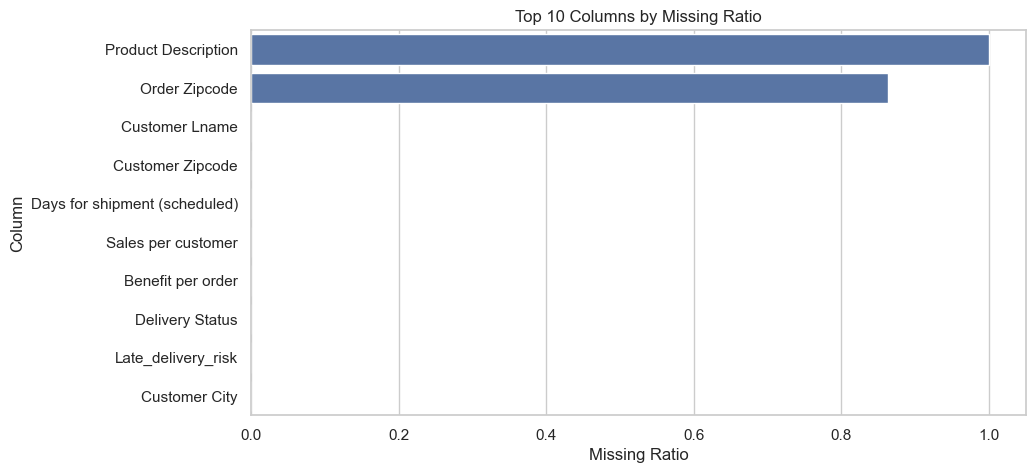

In [31]:
#plotting missingness
top_missing = missing.head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_missing, x="missing_ratio", y="column")
plt.title("Top 10 Columns by Missing Ratio")
plt.xlabel("Missing Ratio")
plt.ylabel("Column")
plt.show()

In [51]:
drop_cols = [
    "Product Description",
    "Order Zipcode",
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer Zipcode",
    "Product Image"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

print("Shape after dropping noisy columns:", df.shape)

Shape after dropping noisy columns: (180519, 44)


In [52]:
df["order_date"] = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")
df["shipping_date"] = pd.to_datetime(df["shipping date (DateOrders)"], errors="coerce")

print("Null order dates:", df["order_date"].isna().sum())
print("Null shipping dates:", df["shipping_date"].isna().sum())

Null order dates: 0
Null shipping dates: 0


In [53]:
print("Min order date:", df["order_date"].min())
print("Max order date:", df["order_date"].max())

Min order date: 2015-01-01 00:00:00
Max order date: 2018-01-31 23:38:00


,order_date,Order Item Quantity
0,2015,138480
1,2016,137352
2,2017,106124
3,2018,2123


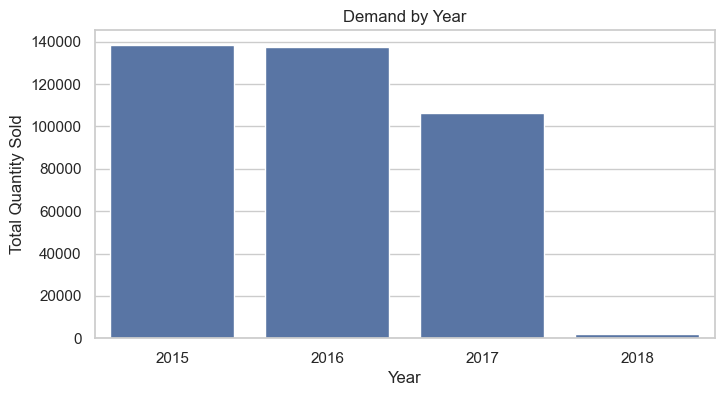

In [54]:
year_demand = (
    df.groupby(df["order_date"].dt.year)["Order Item Quantity"]
      .sum()
      .reset_index()
)

display(year_demand)

plt.figure(figsize=(8, 4))
sns.barplot(data=year_demand, x="order_date", y="Order Item Quantity")
plt.title("Demand by Year")
plt.xlabel("Year")
plt.ylabel("Total Quantity Sold")
plt.show()

In [55]:
df = df[df["order_date"].dt.year < 2018].copy()

print("Shape after removing incomplete 2018:", df.shape)
print("New max order date:", df["order_date"].max())

Shape after removing incomplete 2018: (178396, 46)
New max order date: 2017-12-31 23:52:00


In [56]:
df = df.dropna(subset=["order_date", "Product Card Id", "Order Region", "Order Item Quantity"])
df = df[df["Order Item Quantity"] > 0].copy()

print("Shape after dropping invalid rows:", df.shape)

Shape after dropping invalid rows: (178396, 46)


In [57]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Duplicates removed:", before - after)
print("New shape:", df.shape)

Duplicates removed: 0
New shape: (178396, 46)


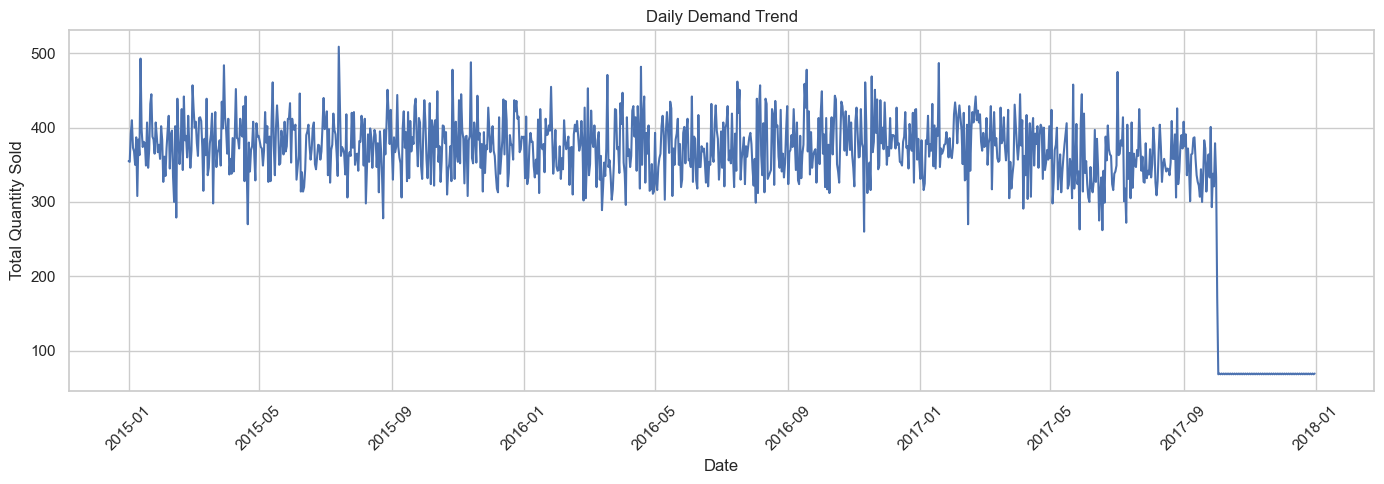

In [58]:
daily_demand = (
    df.groupby(df["order_date"].dt.date)["Order Item Quantity"]
      .sum()
      .reset_index()
)

daily_demand["order_date"] = pd.to_datetime(daily_demand["order_date"])

plt.figure(figsize=(14, 5))
plt.plot(daily_demand["order_date"], daily_demand["Order Item Quantity"])
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
df = df[df["order_date"].dt.year < 2018].copy()

print("New date range:")
print(df["order_date"].min(), "→", df["order_date"].max())

New date range:
2015-01-01 00:00:00 → 2017-12-31 23:52:00


In [64]:
# recompute daily demand AFTER removing 2018

daily_demand = (
    df.groupby(df["order_date"].dt.date)["Order Item Quantity"]
      .sum()
      .reset_index()
)

daily_demand["order_date"] = pd.to_datetime(daily_demand["order_date"])
plt.figure(figsize=(14,5))




<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

In [65]:
df["order_date"].dt.year.value_counts().sort_index()

order_date
2015    62650
2016    62550
2017    53196
Name: count, dtype: int64

In [67]:
daily_demand = (
    df.groupby(df["order_date"].dt.date)["Order Item Quantity"]
      .sum()
      .reset_index()
)

daily_demand["order_date"] = pd.to_datetime(daily_demand["order_date"])

In [68]:
print("Max order_date in df:", df["order_date"].max())
print("Max order_date in daily_demand:", daily_demand["order_date"].max())

display(daily_demand.tail(20))

Max order_date in df: 2017-12-31 23:52:00
Max order_date in daily_demand: 2017-12-31 00:00:00


,order_date,Order Item Quantity
1076,2017-12-12,68
1077,2017-12-13,69
1078,2017-12-14,68
1079,2017-12-15,69
1080,2017-12-16,68
1081,2017-12-17,69
1082,2017-12-18,68
1083,2017-12-19,69
1084,2017-12-20,68
1085,2017-12-21,69


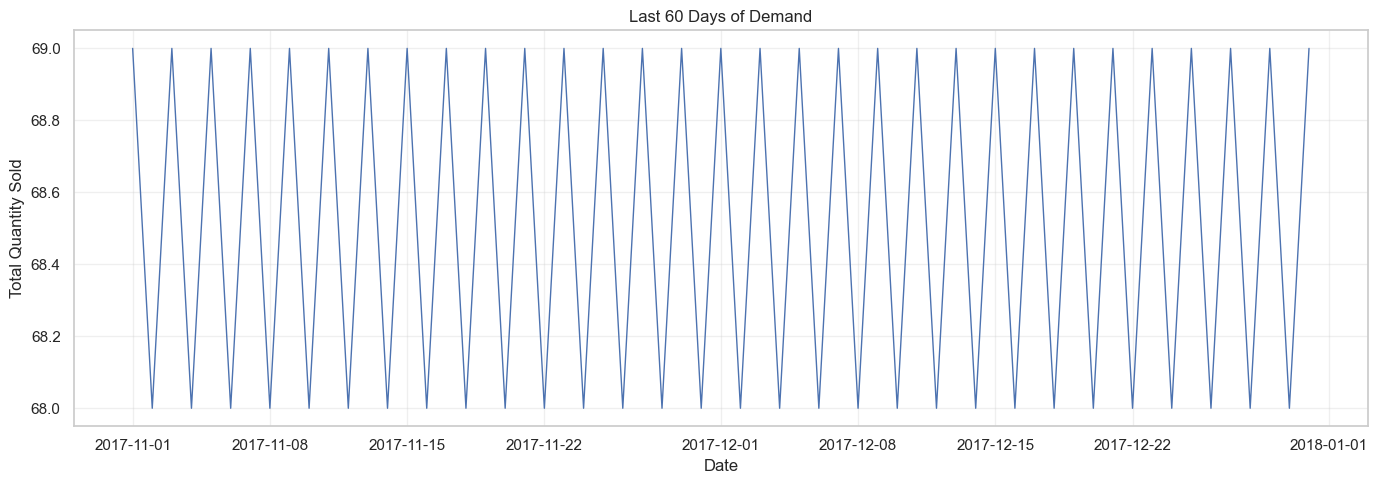

In [69]:
last_60 = daily_demand[daily_demand["order_date"] >= daily_demand["order_date"].max() - pd.Timedelta(days=60)]

plt.figure(figsize=(14,5))
plt.plot(last_60["order_date"], last_60["Order Item Quantity"], linewidth=1)
plt.title("Last 60 Days of Demand")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

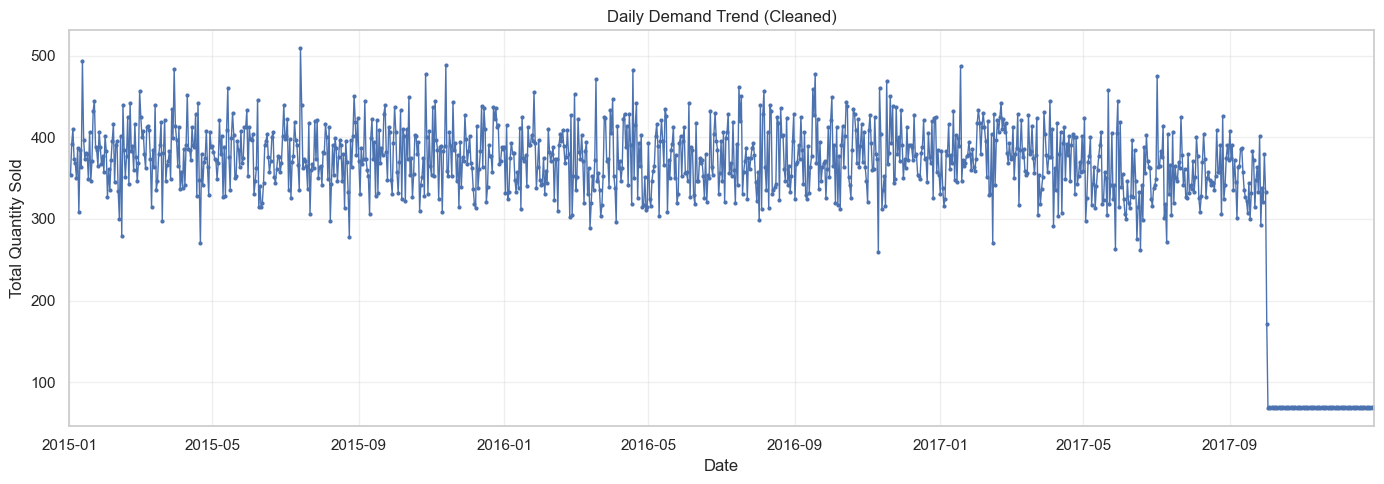

In [70]:
plt.figure(figsize=(14,5))
plt.plot(
    daily_demand["order_date"],
    daily_demand["Order Item Quantity"],
    linewidth=1,
    marker="o",
    markersize=2
)

plt.xlim(daily_demand["order_date"].min(), daily_demand["order_date"].max())
plt.title("Daily Demand Trend (Cleaned)")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
year_demand = (
    df.groupby(df["order_date"].dt.year)["Order Item Quantity"]
      .sum()
      .reset_index()
)

display(year_demand)

,order_date,Order Item Quantity
0,2015,138480
1,2016,137352
2,2017,106124


In [72]:
display(daily_demand.tail(20))
print(df["order_date"].max())
print(daily_demand["order_date"].max())

,order_date,Order Item Quantity
1076,2017-12-12,68
1077,2017-12-13,69
1078,2017-12-14,68
1079,2017-12-15,69
1080,2017-12-16,68
1081,2017-12-17,69
1082,2017-12-18,68
1083,2017-12-19,69
1084,2017-12-20,68
1085,2017-12-21,69


2017-12-31 23:52:00
2017-12-31 00:00:00


In [74]:
df = df[df["order_date"] < "2017-10-01"].copy()

print("New date range:")
print(df["order_date"].min(), "→", df["order_date"].max())

print("\nRows by year:")
display(df["order_date"].dt.year.value_counts().sort_index())

New date range:
2015-01-01 00:00:00 → 2017-09-30 23:59:00

Rows by year:


order_date
2015    62650
2016    62550
2017    46762
Name: count, dtype: int64

In [75]:
df = df.dropna(subset=["order_date", "Product Card Id", "Order Region", "Order Item Quantity"])
df = df[df["Order Item Quantity"] > 0].copy()

print("Shape after dropping invalid rows:", df.shape)

Shape after dropping invalid rows: (171962, 46)


In [76]:
daily_demand = (
    df.groupby(df["order_date"].dt.date)["Order Item Quantity"]
      .sum()
      .reset_index()
)

daily_demand["order_date"] = pd.to_datetime(daily_demand["order_date"])

display(daily_demand.tail())

,order_date,Order Item Quantity
999,2017-09-26,401
1000,2017-09-27,293
1001,2017-09-28,338
1002,2017-09-29,321
1003,2017-09-30,379


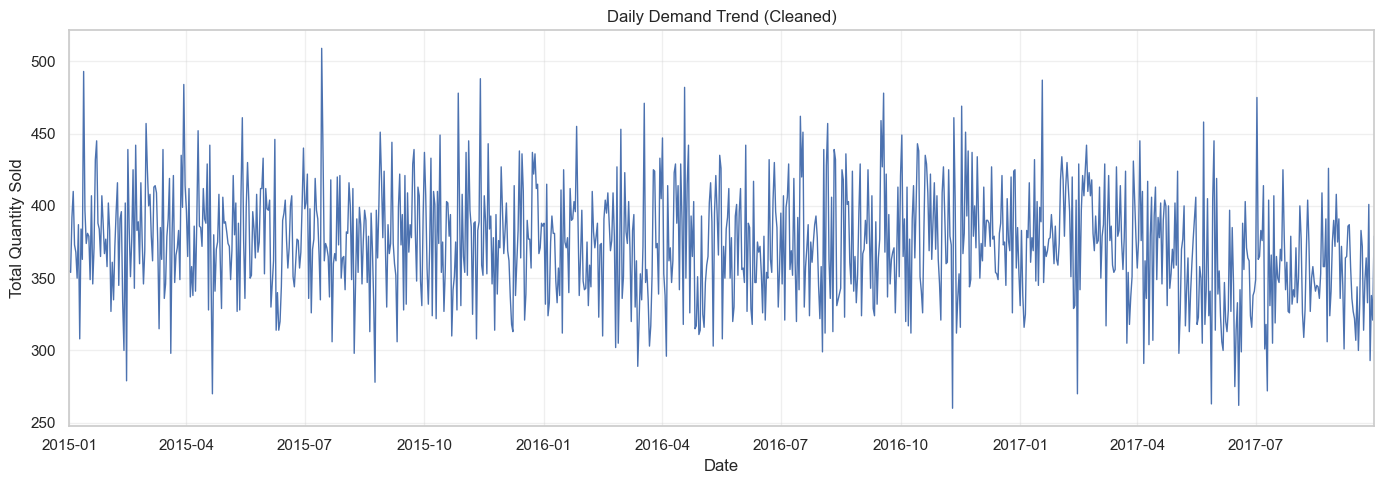

In [77]:
plt.figure(figsize=(14,5))
plt.plot(
    daily_demand["order_date"],
    daily_demand["Order Item Quantity"],
    linewidth=1
)

plt.xlim(daily_demand["order_date"].min(), daily_demand["order_date"].max())
plt.title("Daily Demand Trend (Cleaned)")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

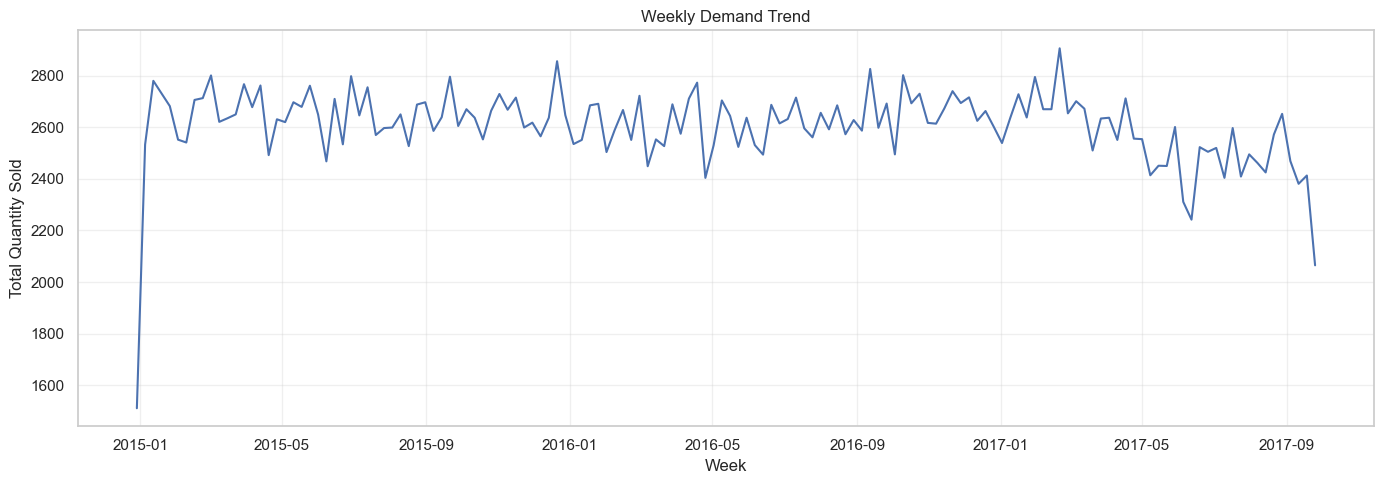

In [78]:
weekly_demand = (
    df.groupby(df["order_date"].dt.to_period("W"))["Order Item Quantity"]
      .sum()
      .reset_index()
)

weekly_demand["week_start"] = weekly_demand["order_date"].apply(lambda x: x.start_time)

plt.figure(figsize=(14,5))
plt.plot(weekly_demand["week_start"], weekly_demand["Order Item Quantity"], linewidth=1.5)
plt.title("Weekly Demand Trend")
plt.xlabel("Week")
plt.ylabel("Total Quantity Sold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

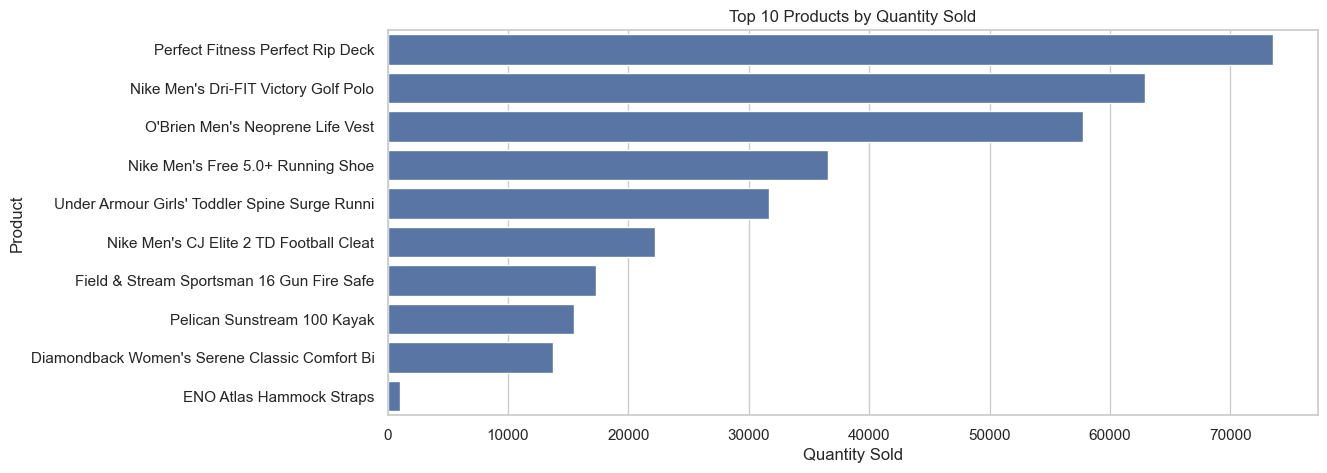

,Product Name,Order Item Quantity
0,Perfect Fitness Perfect Rip Deck,73578
1,Nike Men's Dri-FIT Victory Golf Polo,62878
2,O'Brien Men's Neoprene Life Vest,57735
3,Nike Men's Free 5.0+ Running Shoe,36616
4,Under Armour Girls' Toddler Spine Surge Runni,31710
5,Nike Men's CJ Elite 2 TD Football Cleat,22214
6,Field & Stream Sportsman 16 Gun Fire Safe,17308
7,Pelican Sunstream 100 Kayak,15475
8,Diamondback Women's Serene Classic Comfort Bi,13714
9,ENO Atlas Hammock Straps,998


In [79]:
top_products = (
    df.groupby("Product Name")["Order Item Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_products, x="Order Item Quantity", y="Product Name")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()

display(top_products)

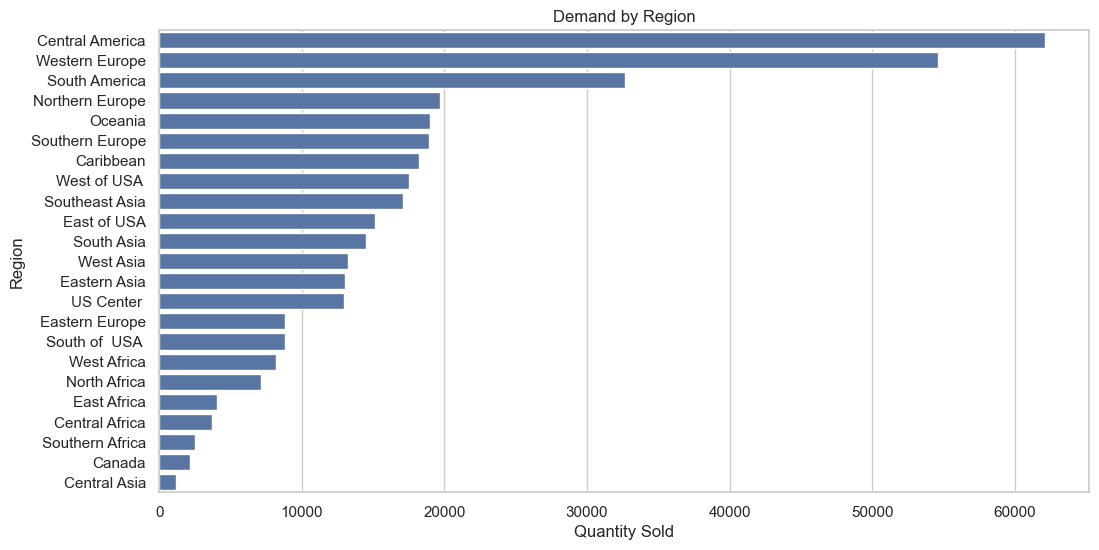

,Order Region,Order Item Quantity
0,Central America,62091
1,Western Europe,54600
2,South America,32647
3,Northern Europe,19723
4,Oceania,18994
5,Southern Europe,18937
6,Caribbean,18204
7,West of USA,17547
8,Southeast Asia,17086
9,East of USA,15108


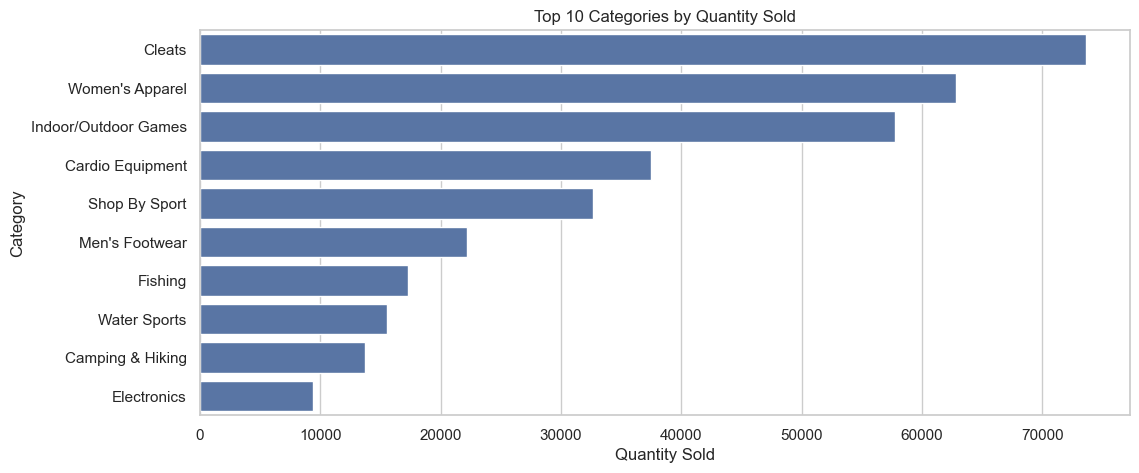

,Category Name,Order Item Quantity
0,Cleats,73614
1,Women's Apparel,62878
2,Indoor/Outdoor Games,57735
3,Cardio Equipment,37523
4,Shop By Sport,32701
5,Men's Footwear,22214
6,Fishing,17308
7,Water Sports,15515
8,Camping & Hiking,13714
9,Electronics,9436


In [80]:
top_regions = (
    df.groupby("Order Region")["Order Item Quantity"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_regions, x="Order Item Quantity", y="Order Region")
plt.title("Demand by Region")
plt.xlabel("Quantity Sold")
plt.ylabel("Region")
plt.show()

display(top_regions)


top_categories = (
    df.groupby("Category Name")["Order Item Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_categories, x="Order Item Quantity", y="Category Name")
plt.title("Top 10 Categories by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Category")
plt.show()

display(top_categories)

In [81]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day
df["dayofweek"] = df["order_date"].dt.dayofweek
df["week"] = df["order_date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["order_date"].dt.quarter
df["week_start"] = df["order_date"].dt.to_period("W").apply(lambda r: r.start_time)

display(df[["order_date", "week_start", "year", "month", "week"]].head())

,order_date,week_start,year,month,week
48,2016-02-24 13:57:00,2016-02-22,2016,2,8
49,2016-10-25 14:39:00,2016-10-24,2016,10,43
50,2016-03-30 04:37:00,2016-03-28,2016,3,13
51,2016-10-30 01:31:00,2016-10-24,2016,10,43
52,2016-11-28 01:18:00,2016-11-28,2016,11,48


In [82]:
keep_cols = [
    "order_date",
    "shipping_date",
    "week_start",
    "Type",
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Category Id",
    "Category Name",
    "Customer City",
    "Customer Country",
    "Customer Segment",
    "Customer State",
    "Department Id",
    "Department Name",
    "Market",
    "Order City",
    "Order Country",
    "Order Item Cardprod Id",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Product Price",
    "Order Item Profit Ratio",
    "Order Item Quantity",
    "Sales",
    "Order Item Total",
    "Order Profit Per Order",
    "Order Region",
    "Order State",
    "Order Status",
    "Product Card Id",
    "Product Category Id",
    "Product Name",
    "Product Price",
    "Product Status",
    "Shipping Mode",
    "year",
    "month",
    "day",
    "dayofweek",
    "week",
    "quarter"
]

keep_cols = [c for c in keep_cols if c in df.columns]
cleaned_orders = df[keep_cols].copy()

print("cleaned_orders shape:", cleaned_orders.shape)
display(cleaned_orders.head())

cleaned_orders shape: (171962, 42)


,order_date,shipping_date,week_start,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Id,Category Name,Customer City,Customer Country,Customer Segment,Customer State,Department Id,Department Name,Market,Order City,Order Country,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,Shipping Mode,year,month,day,dayofweek,week,quarter
48,2016-02-24 13:57:00,2016-02-29 13:57:00,2016-02-22,PAYMENT,2,-30.750000,115.180000,17,Cleats,Bayamon,Puerto Rico,Home Office,PR,4,Apparel,Pacific Asia,Mirzapur,India,365,4.8,0.04,59.990002,-0.27,2,119.980003,115.180000,-30.750000,South Asia,Uttar Pradesh,PENDING_PAYMENT,365,17,Perfect Fitness Perfect Rip Deck,59.990002,0,Second Class,2016,2,24,2,8,1
49,2016-10-25 14:39:00,2016-10-27 14:39:00,2016-10-24,PAYMENT,2,-122.730003,79.180000,29,Shop By Sport,Caguas,Puerto Rico,Home Office,PR,5,Golf,Pacific Asia,Bursa,Turquía,627,0.8,0.01,39.990002,-1.55,2,79.980003,79.180000,-122.730003,West Asia,Bursa,PENDING_PAYMENT,627,29,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,Second Class,2016,10,25,1,43,4
50,2016-03-30 04:37:00,2016-04-05 04:37:00,2016-03-28,PAYMENT,2,33.599998,96.000000,24,Women's Apparel,Caguas,Puerto Rico,Home Office,PR,5,Golf,Pacific Asia,Murray Bridge,Australia,502,4.0,0.04,50.000000,0.35,2,100.000000,96.000000,33.599998,Oceania,Australia del Sur,PENDING_PAYMENT,502,24,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,Second Class,2016,3,30,2,13,1
51,2016-10-30 01:31:00,2016-11-01 01:31:00,2016-10-24,PAYMENT,2,24.690001,75.980003,29,Shop By Sport,Caguas,Puerto Rico,Home Office,PR,5,Golf,Pacific Asia,Kartal,Turquía,627,4.0,0.05,39.990002,0.33,2,79.980003,75.980003,24.690001,West Asia,Estambul,PENDING_PAYMENT,627,29,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,Second Class,2016,10,30,6,43,4
52,2016-11-28 01:18:00,2016-12-01 01:18:00,2016-11-28,PAYMENT,2,9.100000,91.000000,24,Women's Apparel,Caguas,Puerto Rico,Home Office,PR,5,Golf,Pacific Asia,Ulan Bator,Mongolia,502,9.0,0.09,50.000000,0.10,2,100.000000,91.000000,9.100000,Eastern Asia,Ulán Bator,PENDING_PAYMENT,502,24,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,Second Class,2016,11,28,0,48,4


In [83]:
demand_ts = (
    cleaned_orders.groupby(
        ["Product Card Id", "Product Name", "Category Id", "Category Name", "Order Region", "week_start"],
        as_index=False
    )
    .agg(
        demand=("Order Item Quantity", "sum"),
        avg_price=("Product Price", "mean"),
        avg_discount=("Order Item Discount", "mean"),
        avg_sales=("Sales", "mean"),
        avg_profit=("Order Profit Per Order", "mean"),
        shipping_mode_nunique=("Shipping Mode", "nunique"),
        region_order_count=("Order Region", "count"),
    )
)

print("demand_ts shape:", demand_ts.shape)
display(demand_ts.head())

demand_ts shape: (16781, 13)


,Product Card Id,Product Name,Category Id,Category Name,Order Region,week_start,demand,avg_price,avg_discount,avg_sales,avg_profit,shipping_mode_nunique,region_order_count
0,19,Nike Men's Fingertrap Max Training Shoe,2,Soccer,Caribbean,2017-05-01,1,124.989998,6.25,124.989998,-86.089996,1,1
1,19,Nike Men's Fingertrap Max Training Shoe,2,Soccer,Caribbean,2017-05-08,1,124.989998,5.00,124.989998,34.799999,1,1
2,19,Nike Men's Fingertrap Max Training Shoe,2,Soccer,Caribbean,2017-05-15,1,124.989998,3.75,124.989998,9.090000,1,1
3,19,Nike Men's Fingertrap Max Training Shoe,2,Soccer,Caribbean,2017-05-22,2,124.989998,21.25,124.989998,39.275000,1,2
4,19,Nike Men's Fingertrap Max Training Shoe,2,Soccer,Caribbean,2017-06-05,1,124.989998,12.50,124.989998,34.869999,1,1


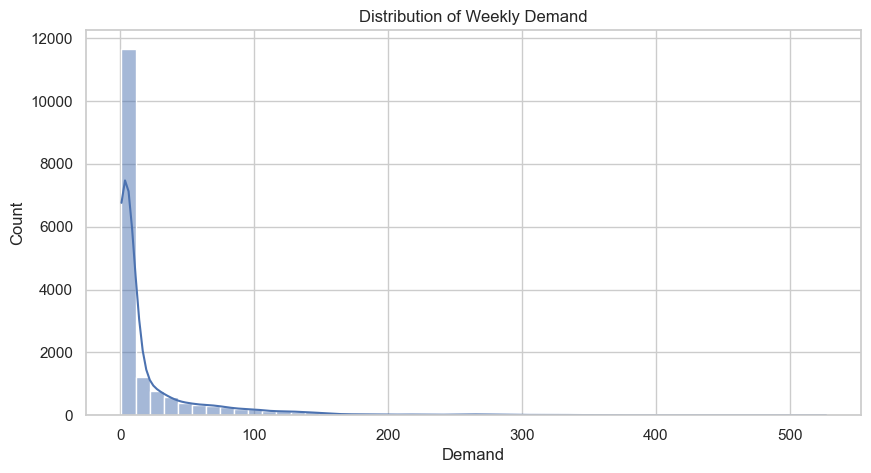

In [84]:
plt.figure(figsize=(10, 5))
sns.histplot(demand_ts["demand"], bins=50, kde=True)
plt.title("Distribution of Weekly Demand")
plt.xlabel("Demand")
plt.show()

In [85]:
cleaned_orders["product_idx"] = pd.factorize(cleaned_orders["Product Card Id"])[0]
cleaned_orders["category_idx"] = pd.factorize(cleaned_orders["Category Id"])[0]
cleaned_orders["region_idx"] = pd.factorize(cleaned_orders["Order Region"])[0]

display(
    cleaned_orders[
        ["Product Card Id", "product_idx", "Category Id", "category_idx", "Order Region", "region_idx"]
    ].head()
)

,Product Card Id,product_idx,Category Id,category_idx,Order Region,region_idx
48,365,0,17,0,South Asia,0
49,627,1,29,1,West Asia,1
50,502,2,24,2,Oceania,2
51,627,1,29,1,West Asia,1
52,502,2,24,2,Eastern Asia,3


In [86]:
cleaned_orders.to_csv(f"{PROCESSED_DIR}/cleaned_orders.csv", index=False)
demand_ts.to_csv(f"{PROCESSED_DIR}/demand_timeseries.csv", index=False)

print("Saved:")
print(f"{PROCESSED_DIR}/cleaned_orders.csv")
print(f"{PROCESSED_DIR}/demand_timeseries.csv")

Saved:
../data/processed/cleaned_orders.csv
../data/processed/demand_timeseries.csv
